In [1]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [12]:
# Set seed for reproducibility
torch.manual_seed(42)

# --- 1. DATA PREPARATION ---
# MNIST images are 28x28 pixels = 784 total inputs
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform = transform)
test_dataset  = datasets.MNIST(root = './data', train = True, download=True, transform=transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
class SimpleAutoencoder(nn.Module):
    def __init__(self, input_dim=784, bottleneck_dim=16):
        super(SimpleAutoencoder, self).__init__()
        # --- Encoder Layers ---
        self.encode = nn.Linear(input_dim, bottleneck_dim)
        # --- Decoder Layers ---
        self.decode = nn.Linear(bottleneck_dim, input_dim)
        # --- Activations ---
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = x.view(x.size(0), -1)       # Flatten image: (batch_size, 1, 28, 28) -> (batch_size, 784)
        # 1. Encode
        encode = self.relu(self.encode(x))
        # 2. Decode
        decoded = self.decode(encode)
        output = decoded.view(x.size(0), 1, 28, 28)
                              # Reshape back to image: (batch_size, 1, 28, 28)
        return output

In [22]:
class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim=784, bottleneck_dim=16):
        super(DeepAutoencoder, self).__init__()
        
        # --- Encoder Layers (784 -> 128 -> 64 -> 16) ---
        self.encode1 = nn.Linear(input_dim, 128)
        self.encode2 = nn.Linear(128, 64)
        self.encode3 = nn.Linear(64, 16)        
        # --- Decoder Layers (16 -> 64 -> 128 -> 784) ---
        self.decode1 = nn.Linear(16, 64)
        self.decode2 = nn.Linear(64, 128)
        self.decode3 = nn.Linear(128, input_dim)
        # --- Activations ---x
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Flatten image: (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.view(x.size(0), -1)
        encoded1 = self.relu(self.encode1(x))
        encoded2 = self.relu(self.encode2(encoded1))
        encoded3 = self.relu(self.encode3(encoded2))
        # --- ENCODER PASS ---
        
        decoded1 = self.relu(self.decode1(encoded3))
        decoded2 = self.relu(self.decode2(decoded1))
        decoded3 = self.sigmoid(self.decode3(decoded2))
        # --- DECODER PASS ---
        
        output = decoded3.view(x.size(0), 1, 28, 28)
        # Reshape back to image: (batch_size, 1, 28, 28)
        
        return output

In [23]:
def train_autoencoder(model, train_loader, epochs=5, lr=0.001):
    criterion = nn.MSELoss() # Comparing raw output pixels to raw input pixels
    optimizer = optim.Adam(model.parameters(), lr = lr)

    print(f"Training {model.__class__.__name__}...")
    for epoch in range(1, epochs + 1):
        running_loss = 0.0
        for images, _ in train_loader:  # Note: Labels '_' are ignored!
            optimizer.zero_grad()
            reconst =  model(images)                      # Target is the input image itself
            loss = criterion(reconst, images)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch {epoch:02d} | Reconstruct Loss (MSE): {epoch_loss:.5f}")
    print("Training Complete!\n")
    return model

In [24]:
simple_model = SimpleAutoencoder(bottleneck_dim=16)
simple_model = train_autoencoder(simple_model, train_loader, epochs=5)

# Train Deep Model
deep_model = DeepAutoencoder(bottleneck_dim=16)
deep_model = train_autoencoder(deep_model, train_loader, epochs=5)

Training SimpleAutoencoder...
Epoch 01 | Reconstruct Loss (MSE): 0.06245
Epoch 02 | Reconstruct Loss (MSE): 0.04643
Epoch 03 | Reconstruct Loss (MSE): 0.04510
Epoch 04 | Reconstruct Loss (MSE): 0.04503
Epoch 05 | Reconstruct Loss (MSE): 0.04500
Training Complete!

Training DeepAutoencoder...
Epoch 01 | Reconstruct Loss (MSE): 0.05067
Epoch 02 | Reconstruct Loss (MSE): 0.02653
Epoch 03 | Reconstruct Loss (MSE): 0.02199
Epoch 04 | Reconstruct Loss (MSE): 0.01964
Epoch 05 | Reconstruct Loss (MSE): 0.01855
Training Complete!



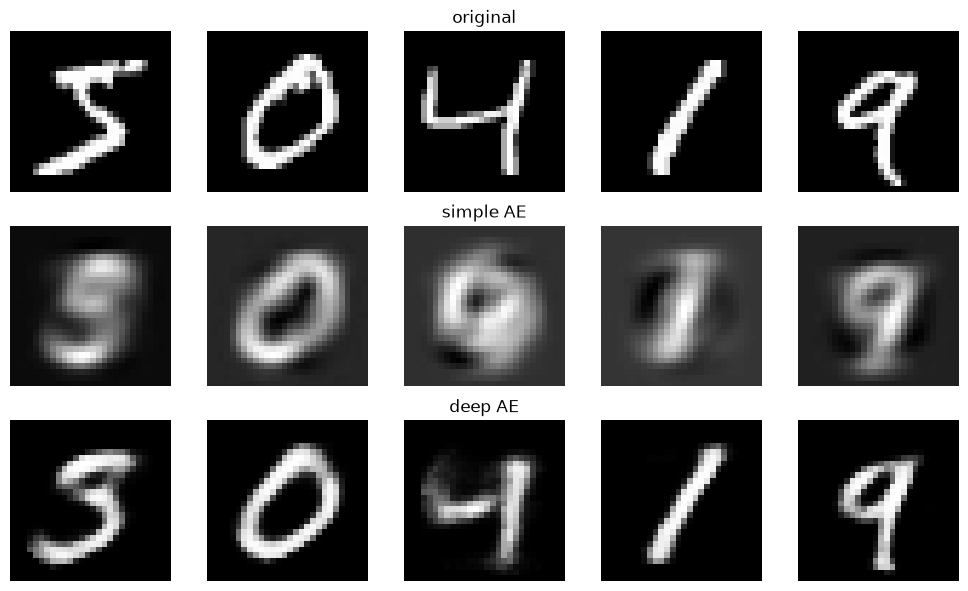

In [29]:
def visualize_results(simple_net, deep_net, loader):
    simple_net.eval()
    deep_net.eval()
    
    # Grab one batch of test images
    images, _ = next(iter(loader))
    with torch.no_grad():
        simple_output = simple_net(images)
        deep_output = deep_net(images)

    num_sample = 5
    plt.figure(figsize=(10,6))
    for i in range(num_sample):
        ax = plt.subplot(3, num_sample, i+1)
        plt.imshow(images[i].squeeze(), cmap = "gray")
        plt.title("original") if i == 2 else None
        plt.axis('off')
    # Plot original vs. simple reconstructed vs. deep reconstructed

        ax = plt.subplot(3, num_sample, i+1+num_sample)
        plt.imshow(simple_output[i].squeeze(), cmap = "gray")
        plt.title("simple AE") if i == 2 else None
        plt.axis('off')

        ax = plt.subplot(3, num_sample, i+1+2*num_sample)
        plt.imshow(deep_output[i].squeeze(), cmap = "gray")
        plt.title("deep AE") if i == 2 else None
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_results(simple_model, deep_model, test_loader)